In [ ]:
# If your company give you high-dimensional data… how would you decide what information matters? 

In [ ]:
# PCA

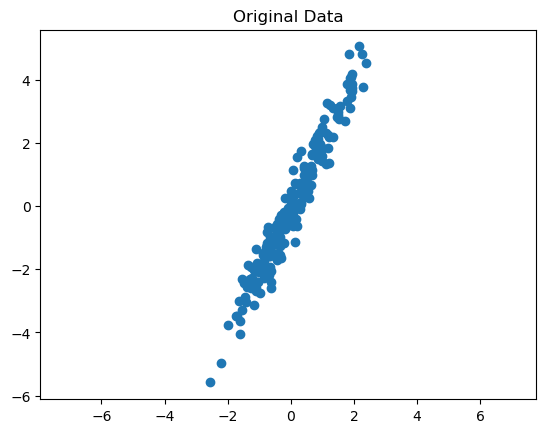

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
x = np.random.randn(200)
y = 2*x + np.random.randn(200)*0.5

plt.scatter(x, y)
plt.title("Original Data")
plt.axis('equal')
plt.show()

In [ ]:
# If you had to represent this with ONE number, what direction would you choose? 

In [2]:
from sklearn.decomposition import PCA

X = np.vstack((x, y)).T
pca = PCA(n_components=1)
pca.fit(X)

direction = pca.components_[0]

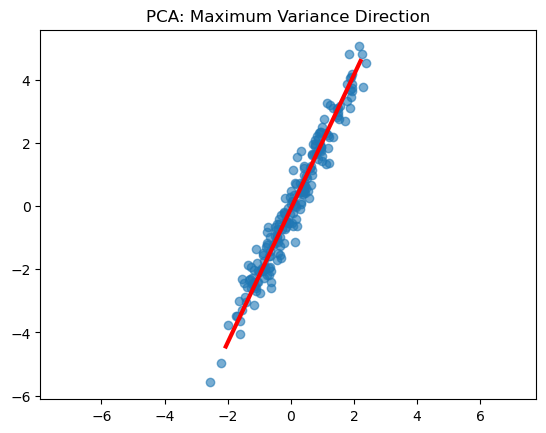

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Create correlated data
np.random.seed(0)
x = np.random.randn(200)
y = 2*x + np.random.randn(200)*0.5

X = np.vstack((x, y)).T

# Fit PCA
pca = PCA(n_components=1)
pca.fit(X)

# Get direction and mean
direction = pca.components_[0]
mean = np.mean(X, axis=0)

# Create line for plotting
t = np.linspace(-5, 5, 100)
line = mean + np.outer(t, direction)

# Plot
plt.figure()
plt.scatter(X[:,0], X[:,1], alpha=0.6)
plt.plot(line[:,0], line[:,1], 'r', linewidth=3)

plt.title("PCA: Maximum Variance Direction")
plt.axis('equal')
plt.show()

In [ ]:
# PCA chooses this red line because data spreads the most along it

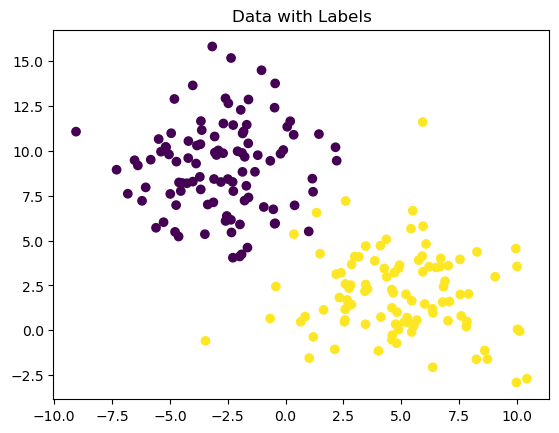

In [3]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=200, centers=2, random_state=42, cluster_std=2.5)

plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Data with Labels")
plt.show()

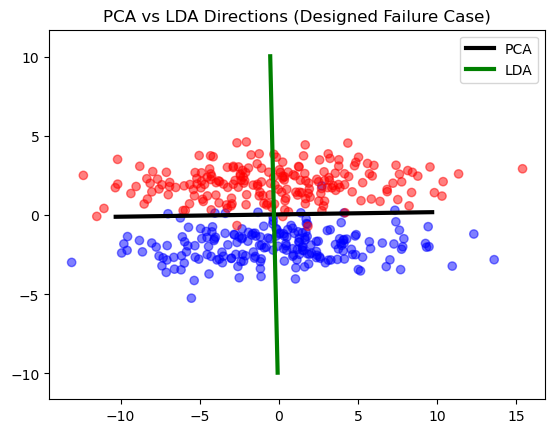

C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


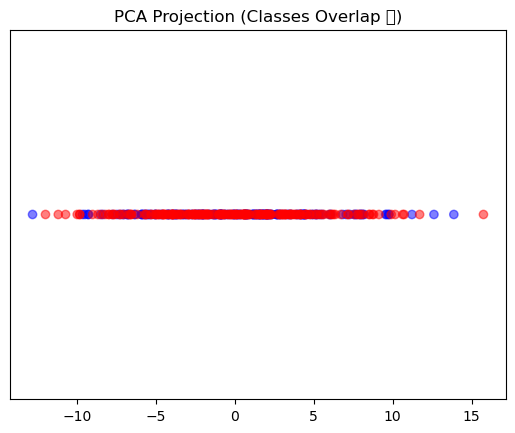

C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


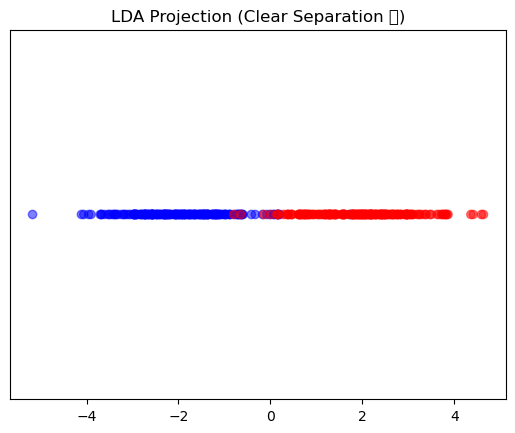

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

np.random.seed(42)

# Create dataset
n = 200

# Class 0 (bottom cluster)
x0 = np.random.normal(0, 5, n)   # large horizontal spread
y0 = np.random.normal(-2, 1, n)

# Class 1 (top cluster)
x1 = np.random.normal(0, 5, n)
y1 = np.random.normal(2, 1, n)

X = np.vstack((np.column_stack((x0, y0)), np.column_stack((x1, y1))))
y = np.array([0]*n + [1]*n)

# -------------------
# PCA
# -------------------
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)
pca_dir = pca.components_[0]

# -------------------
# LDA
# -------------------
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X, y)
lda_dir = lda.coef_[0]
lda_dir = lda_dir / np.linalg.norm(lda_dir)

# -------------------
# Plot original data with directions
# -------------------
mean = np.mean(X, axis=0)
t = np.linspace(-10, 10, 100)

line_pca = mean + np.outer(t, pca_dir)
line_lda = mean + np.outer(t, lda_dir)

plt.figure()
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', alpha=0.5)

plt.plot(line_pca[:,0], line_pca[:,1], 'k', linewidth=3, label='PCA')
plt.plot(line_lda[:,0], line_lda[:,1], 'g', linewidth=3, label='LDA')

plt.legend()
plt.title("PCA vs LDA Directions (Designed Failure Case)")
plt.axis('equal')
plt.show()

# -------------------
# PCA Projection
# -------------------
plt.figure()
plt.scatter(X_pca, np.zeros_like(X_pca), c=y, cmap='bwr', alpha=0.5)
plt.title("PCA Projection (Classes Overlap )")
plt.yticks([])
plt.show()

# -------------------
# LDA Projection
# -------------------
plt.figure()
plt.scatter(X_lda, np.zeros_like(X_lda), c=y, cmap='bwr', alpha=0.5)
plt.title("LDA Projection (Clear Separation )")
plt.yticks([])
plt.show()

In [14]:
import numpy as np

# PCA projection
X_pca = pca.transform(X)

# LDA projection
X_lda = lda.transform(X)

# Means
print("PCA class means:")
print(np.mean(X_pca[y==0]), np.mean(X_pca[y==1]))

print("\nLDA class means:")
print(np.mean(X_lda[y==0]), np.mean(X_lda[y==1]))

# Variance within class
print("\nPCA within-class variance:")
print(np.var(X_pca[y==0]), np.var(X_pca[y==1]))

print("\nLDA within-class variance:")
print(np.var(X_lda[y==0]), np.var(X_lda[y==1]))

PCA class means:
0.08375120823684494 -0.08375120823684444

LDA class means:
-1.9673686999254791 1.96736869992548

PCA within-class variance:
21.5691452339668 24.59001379167751

LDA within-class variance:
0.9638838443003359 1.026116155699664


In [ ]:
# Another example 

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Load dataset
data = load_iris()
X = data.data[:, :2]   # only first 2 features (hard case)
y = data.target

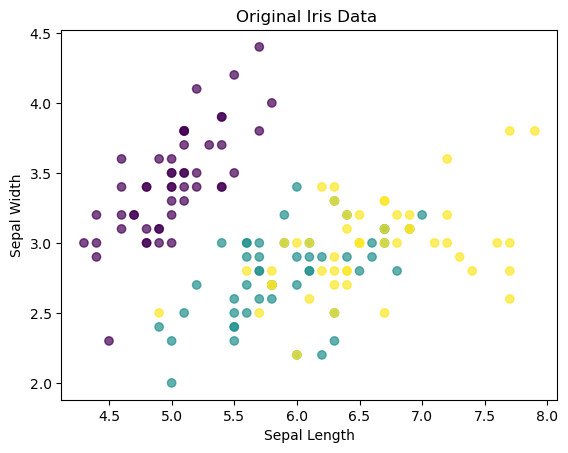

In [21]:
plt.figure()
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=0.7)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Original Iris Data ")
plt.show()

In [17]:
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)

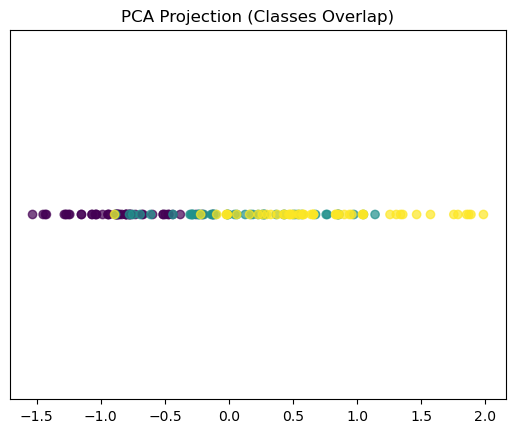

In [22]:
plt.figure()
plt.scatter(X_pca, np.zeros_like(X_pca), c=y, cmap='viridis', alpha=0.7)
plt.title("PCA Projection (Classes Overlap)")
plt.yticks([])
plt.show()

In [19]:
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X, y)

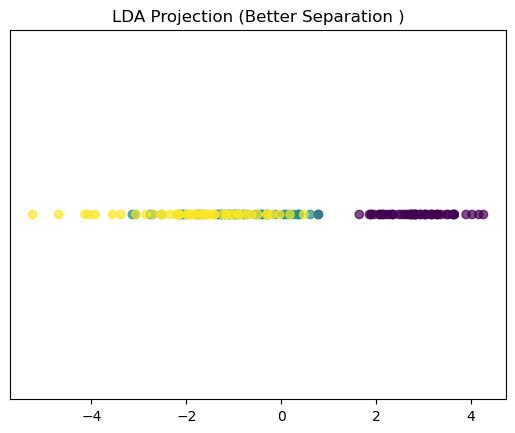

In [23]:
plt.figure()
plt.scatter(X_lda, np.zeros_like(X_lda), c=y, cmap='viridis', alpha=0.7)
plt.title("LDA Projection (Better Separation )")
plt.yticks([])
plt.show()

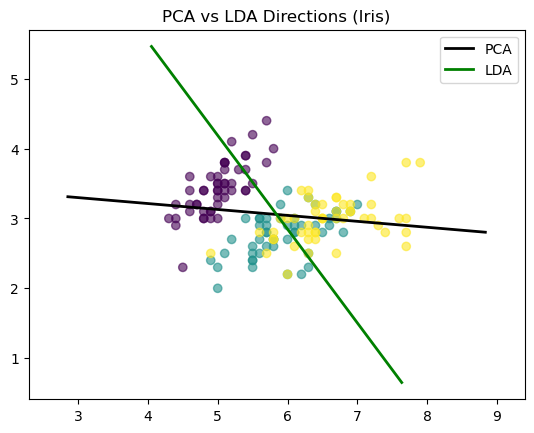

In [26]:
# PCA direction
pca_dir = pca.components_[0]

# LDA direction
lda_dir = lda.coef_[0]
lda_dir = lda_dir / np.linalg.norm(lda_dir)

mean = np.mean(X, axis=0)
t = np.linspace(-3, 3, 100)

line_pca = mean + np.outer(t, pca_dir)
line_lda = mean + np.outer(t, lda_dir)

plt.figure()
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=0.6)

plt.plot(line_pca[:,0], line_pca[:,1], 'k', label='PCA', linewidth=2)
plt.plot(line_lda[:,0], line_lda[:,1], 'g', label='LDA', linewidth=2)

plt.legend()
plt.title("PCA vs LDA Directions (Iris)")
plt.axis('equal')
plt.show()

In [25]:
PCA direction → follows overall spread
LDA direction → aligns to separate classes

In [ ]:
| Aspect                        | PCA (Principal Component Analysis)          | LDA (Linear Discriminant Analysis)          |
| ----------------------------- | ------------------------------------------- | ------------------------------------------- |
| **Type**                      | Unsupervised                                | Supervised                                  |
| **Uses labels?**              |   No                                        |   Yes                                       |
| **Goal**                      | Maximize variance                           | Maximize class separability                 |
| **Core idea**                 | Preserve information                        | Improve discrimination                      |
| **Output directions**         | Up to `min(n_features, n_samples)`          | Up to `n_classes - 1`                       |
| **Works when labels absent?** |   Yes                                       |   No                                        |
| **Best for**                  | Compression, visualization, noise reduction | Classification preprocessing                |
| **Focuses on**                | Global structure of data                    | Class boundaries                            |
| **Sensitive to scaling**      |   Yes                                       |   Yes                                       |
| **Assumption**                | No strong assumption                        | Classes roughly Gaussian + equal covariance |
| **Failure case**              | When variance ≠ important info              | When classes overlap heavily or non-linear  |
| **Interpretability**          | Moderate                                    | Often more interpretable for classification |


In [29]:
# other dimensionality reduction technique

| Method      | Type       | Uses Labels? | Best For                   | Output Use   |
| ----------- | ---------- | ------------ | -------------------------- | ------------ |
| PCA         | Linear     | N            | Compression, preprocessing | ML models    |
| LDA         | Linear     | Y            | Classification             | ML models    |
| t-SNE       | Non-linear | N            | Visualization              | Not for ML |
| UMAP        | Non-linear | N            | Visualization + structure  | Sometimes ML |
| Kernel PCA  | Non-linear | N            | Complex patterns           | ML models    |
| Autoencoder | Non-linear | N            | Deep feature learning      | ML models    |


SyntaxError: invalid syntax (2105496581.py, line 3)